# Visualization

- Models: 
    - mbert: https://huggingface.co/facebook/mbart-large-50-many-to-many-mmt
    - opus-mt: https://huggingface.co/Helsinki-NLP/opus-mt-zh-en
    - nllb: https://huggingface.co/facebook/nllb-200-distilled-600M
    - t5-small: https://huggingface.co/google-t5/t5-small

- Dataset: WMT-17, zh-en
    - https://huggingface.co/datasets/wmt/wmt17

- Metrics:
    - sacre-BLEU: https://github.com/mjpost/sacrebleu
    - CHRF: https://machinetranslate.org/chrF
    - Loss: Cross-Entropy Loss

In [14]:
import numpy as np
import random
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## Load Experimental Data

In [15]:
def load_data(path: str) -> pd.DataFrame:
    df = pd.read_json(path, lines=True)

    df = pd.melt(df, id_vars=['src', 'tgt', 'num_train', 'num_test', 'num_val', 'model_name'],
             value_vars=['eval_bleu', 'eval_chrf', 'eval_loss'],
             var_name='metric',
             value_name='value')
    return df

In [16]:
df = load_data('./wmt17_results.jsonl')

In [17]:
df.head()

,src,tgt,num_train,num_test,num_val,model_name,metric,value
0,zh,en,64,20,32,opus-mt,eval_bleu,53.734489
1,zh,en,128,20,64,opus-mt,eval_bleu,40.911876
2,zh,en,128,200,64,mbart,eval_bleu,30.678802
3,zh,en,16,200,8,mbart,eval_bleu,32.709235
4,zh,en,128,20,64,opus-mt,eval_bleu,40.911876


## Inspect the Result Data

In [18]:
df.src.unique(), df.tgt.unique() # Only zh-en.

(array(['zh'], dtype=object), array(['en'], dtype=object))

In [19]:
df.num_test.unique() # num_test is fixed to 20.

array([ 20, 200])

In [20]:
x = sorted(df.num_train.unique()) # num_train is from 10 to 90.

In [21]:
df.model_name.unique() # mBERT and OPUS-MT.

array(['opus-mt', 'mbart'], dtype=object)

In [22]:
df.columns

Index(['src', 'tgt', 'num_train', 'num_test', 'num_val', 'model_name',
       'metric', 'value'],
      dtype='object')

In [23]:
df.metric.unique() # 'eval_bleu', 'eval_chrf', 'eval_loss'

array(['eval_bleu', 'eval_chrf', 'eval_loss'], dtype=object)

## Analyze the Results

Repeat time is 3.

Comparing two different models on three metrics.

In [24]:
def plot(df):
    plt.figure(figsize=(12, 3))
    ax=plt.subplot(131)
    sns.barplot(data=df[df.metric=='eval_bleu'], x='num_train', y='value', hue='model_name', errorbar='sd', ax=ax)
    ax.set_title('BLEU Score vs Number of Training Samples')
    ax.set_xlabel('Number of Training Samples')
    ax.set_ylabel(r'BLEU Score $\uparrow$')
    ax.legend().set_label(None)
    ax=plt.subplot(132)
    sns.barplot(data=df[df.metric=='eval_chrf'], x='num_train', y='value', hue='model_name', errorbar='sd', ax=ax)
    ax.set_title('ChrF Score vs Number of Training Samples')
    ax.set_xlabel('Number of Training Samples')
    ax.set_ylabel(r'ChrF Score $\uparrow$')
    ax.legend().set_label(None)
    ax=plt.subplot(133)
    sns.barplot(data=df[df.metric=='eval_loss'], x='num_train', y='value', hue='model_name', errorbar='sd', ax=ax)
    ax.set_title('Evaluation Loss vs Number of Training Samples')
    ax.set_xlabel('Number of Training Samples')
    ax.set_ylabel(r'Evaluation Loss $\downarrow$')
    ax.legend().set_label(None)
    plt.suptitle('Performance of two models on three metrics with varying train sizes.')
    plt.tight_layout()
    plt.show()

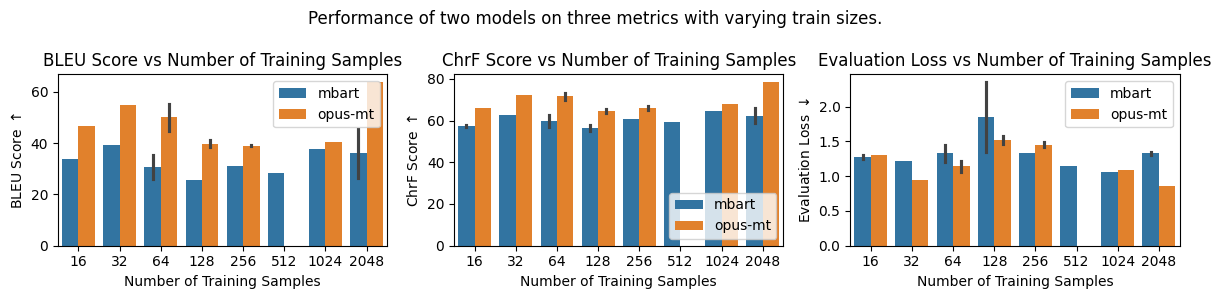

In [25]:
plot(df[df.num_test == 20])

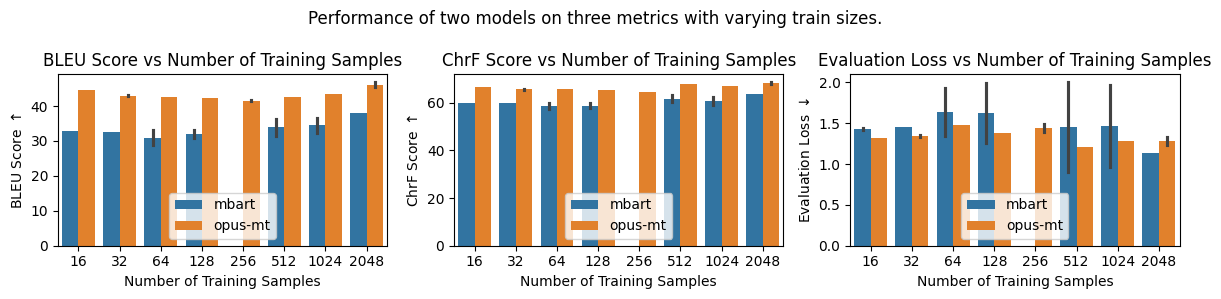

In [26]:
plot(df[df.num_test == 200])